In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Download NLTK stopwords
nltk.download('stopwords')

print("Libraries imported successfully.")

c:\Users\HP\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Libraries imported successfully.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv('Final_Data.csv')

print("First 5 rows:")
display(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

First 5 rows:


,review_description,rating,company
0,رائع,positive,talbat
1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,positive,talbat
2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,negative,talbat
3,لماذا لا يمكننا طلب من ماكدونالدز؟,negative,talbat
4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,negative,talbat



Dataset shape:
(40046, 3)

Column names:
['review_description', 'rating', 'company']


In [3]:
# ============================================================
# 3. BASIC DATA INFORMATION
# ============================================================

print("DataFrame Info:")
df.info()

print("\nDescriptive Statistics:")
display(df.describe(include='all'))

print("\nMissing Values:")
display(df.isnull().sum())

DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 40046 entries, 0 to 40045
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   review_description  40045 non-null  str  
 1   rating              40046 non-null  str  
 2   company             40046 non-null  str  
dtypes: str(3)
memory usage: 5.0 MB

Descriptive Statistics:


,review_description,rating,company
count,40045,40046,40046
unique,38999,3,12
top,ممتاز,positive,talbat
freq,16,23921,32073



Missing Values:


review_description    1
rating                0
company               0
dtype: int64

In [4]:
# ============================================================
# 4. HANDLE MISSING VALUES
# ============================================================

# Remove rows where review description is missing
df.dropna(subset=['review_description'], inplace=True)

# Remove rows where sentiment/rating is missing
df.dropna(subset=['rating'], inplace=True)

# Reset index after removing rows
df.reset_index(drop=True, inplace=True)

print("Shape after removing missing values:")
print(df.shape)

print("\nMissing values after cleaning:")
display(df.isnull().sum())

Shape after removing missing values:
(40045, 3)

Missing values after cleaning:


review_description    0
rating                0
company               0
dtype: int64

In [5]:
# ============================================================
# 5. RENAME TARGET COLUMN
# ============================================================

# 'rating' actually contains sentiment labels
df.rename(columns={'rating': 'sentiment'}, inplace=True)

print("Sentiment classes:")
print(df['sentiment'].unique())

print("\nSentiment distribution:")
display(df['sentiment'].value_counts())

Sentiment classes:
<ArrowStringArray>
['positive', 'negative', 'neutral']
Length: 3, dtype: str

Sentiment distribution:


sentiment
positive    23921
negative    14199
neutral      1925
Name: count, dtype: int64

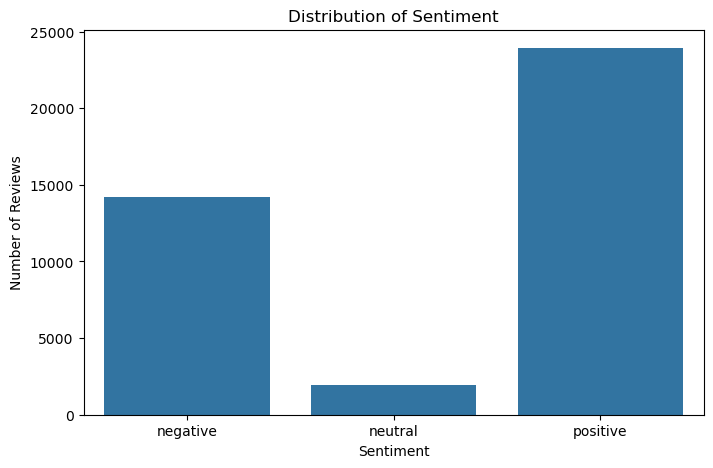

In [6]:
# ============================================================
# 6. SENTIMENT DISTRIBUTION
# ============================================================

sentiment_order = ['negative', 'neutral', 'positive']

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='sentiment',
    order=sentiment_order
)

plt.title('Distribution of Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.show()

In [7]:
# ============================================================
# 7. SENTIMENT PERCENTAGES
# ============================================================

sentiment_percentage = (
    df['sentiment']
    .value_counts(normalize=True)
    .reindex(sentiment_order)
    .mul(100)
    .round(2)
)

print("Sentiment percentages:")
display(sentiment_percentage)

Sentiment percentages:


sentiment
negative    35.46
neutral      4.81
positive    59.74
Name: proportion, dtype: float64

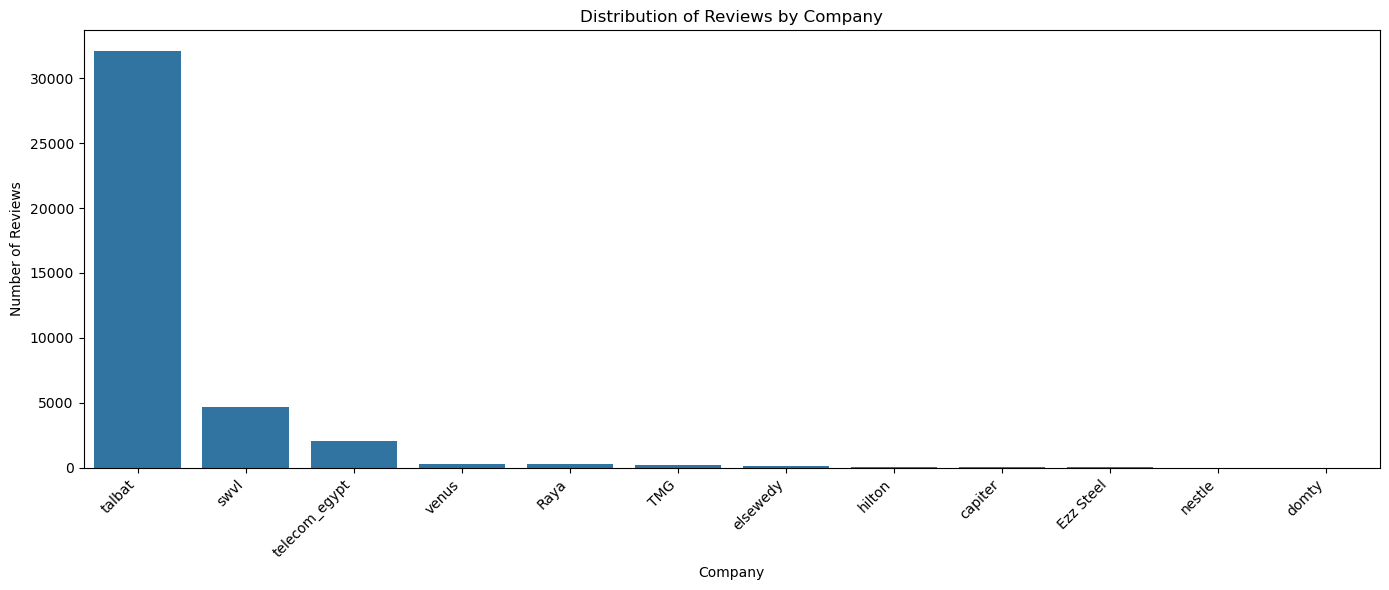

In [8]:
# ============================================================
# 8. COMPANY DISTRIBUTION
# ============================================================

plt.figure(figsize=(14, 6))

sns.countplot(
    data=df,
    x='company',
    order=df['company'].value_counts().index
)

plt.title('Distribution of Reviews by Company')
plt.xlabel('Company')
plt.ylabel('Number of Reviews')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

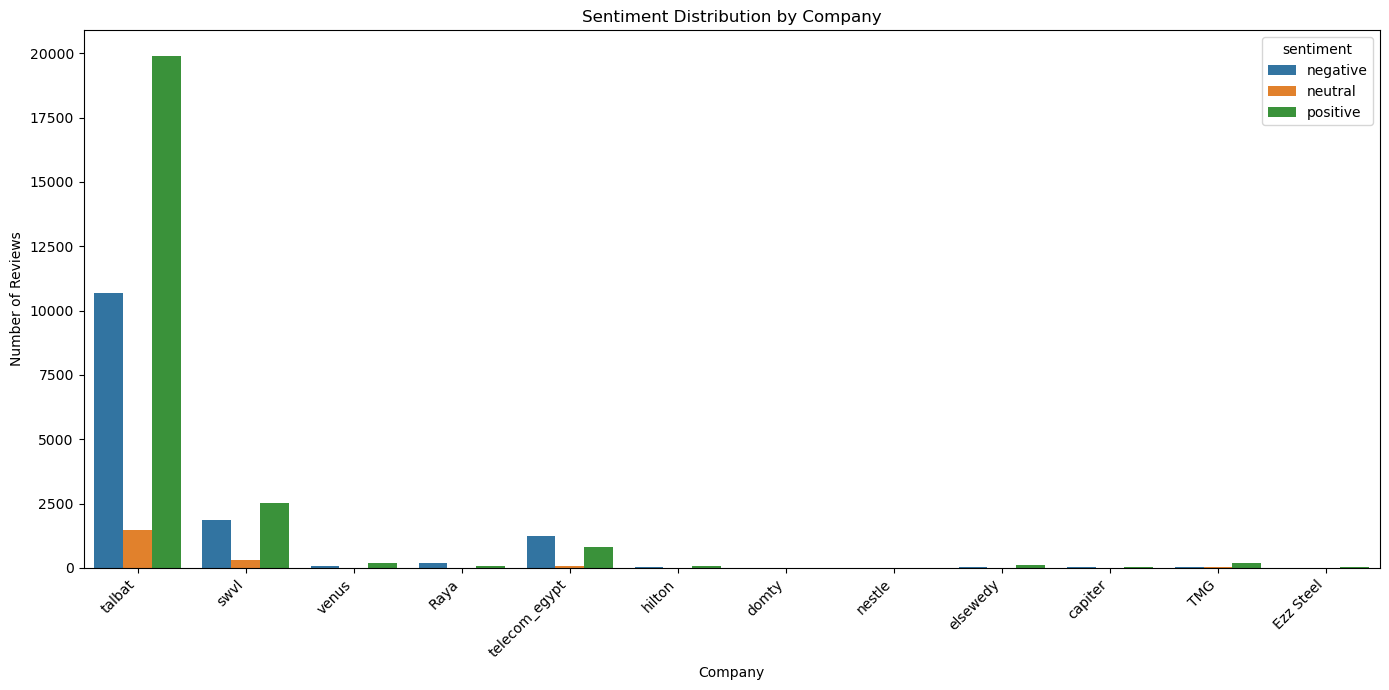

In [9]:
# ============================================================
# 9. SENTIMENT BY COMPANY
# ============================================================

plt.figure(figsize=(14, 7))

sns.countplot(
    data=df,
    x='company',
    hue='sentiment',
    hue_order=sentiment_order
)

plt.title('Sentiment Distribution by Company')
plt.xlabel('Company')
plt.ylabel('Number of Reviews')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# 10. ARABIC TEXT CLEANING
# ============================================================

def clean_arabic_text(text):
    text = str(text)

    # Remove Arabic diacritics (Tashkeel)
    text = re.sub(r'[\u064B-\u065F\u0670]', '', text)

    # Normalize different forms of Alef
    text = re.sub(r'[إأآا]', 'ا', text)

    # Normalize Alef Maqsura
    text = re.sub(r'ى', 'ي', text)

    # Normalize Ta Marbuta
    text = re.sub(r'ة', 'ه', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Keep Arabic characters and whitespace
    text = re.sub(r'[^\u0600-\u06FF\s]', ' ', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text)

    # Remove leading/trailing whitespace
    text = text.strip()

    return text


df['cleaned_review'] = df['review_description'].apply(
    clean_arabic_text
)

print("Original vs cleaned reviews:")
display(
    df[
        ['review_description', 'cleaned_review']
    ].head(10)
)

Original vs cleaned reviews:


,review_description,cleaned_review
0,رائع,رائع
1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,برنامج رائع جدا يساعد علي تلبيه الاحتياجات بشك...
2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...
3,لماذا لا يمكننا طلب من ماكدونالدز؟,لماذا لا يمكننا طلب من ماكدونالدز؟
4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...
5,أصبح غالي جداً,اصبح غالي جدا
6,جميل جدا رائع. . .,جميل جدا رائع
7,للأسف الواحد ينصدم بعد زيادة الاسعار و للاسف ب...,للاسف الواحد ينصدم بعد زياده الاسعار و للاسف ب...
8,برنامج توترز توصيل احلى من برنامجكم فاشل,برنامج توترز توصيل احلي من برنامجكم فاشل
9,كتير في تحسن خدمة العملاء لطفين في بعض الاخطاء...,كتير في تحسن خدمه العملاء لطفين في بعض الاخطاء...


In [11]:
# ============================================================
# 11. ARABIC STOPWORDS
# ============================================================

arabic_stopwords = set(
    stopwords.words('arabic')
)

print("Number of Arabic stopwords:")
print(len(arabic_stopwords))

Number of Arabic stopwords:
701


In [12]:
# ============================================================
# 12. PRESERVE IMPORTANT NEGATION WORDS
# ============================================================

important_negations = {
    'مش',
    'موش',
    'لا',
    'ما',
    'مفيش',
    'ليس',
    'لم',
    'لن'
}

# Remove important sentiment-related negations
# from the stopword list
arabic_stopwords -= important_negations

print("Important negation words preserved:")
print(important_negations)

Important negation words preserved:
{'لن', 'ليس', 'مفيش', 'مش', 'موش', 'لا', 'لم', 'ما'}


In [13]:
# ============================================================
# 13. REMOVE STOPWORDS
# ============================================================

def remove_stopwords(text):
    words = text.split()

    filtered_words = [
        word
        for word in words
        if word not in arabic_stopwords
    ]

    return ' '.join(filtered_words)


df['review_no_stopwords'] = (
    df['cleaned_review']
    .apply(remove_stopwords)
)

print("Before vs after stopword removal:")
display(
    df[
        ['cleaned_review', 'review_no_stopwords']
    ].head(10)
)

Before vs after stopword removal:


,cleaned_review,review_no_stopwords
0,رائع,رائع
1,برنامج رائع جدا يساعد علي تلبيه الاحتياجات بشك...,برنامج رائع جدا يساعد علي تلبيه الاحتياجات بشك...
2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...
3,لماذا لا يمكننا طلب من ماكدونالدز؟,لماذا لا يمكننا طلب ماكدونالدز؟
4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,البرنامج بيظهر المطاعم مغلقه انها بتكون فاتحه ...
5,اصبح غالي جدا,اصبح غالي جدا
6,جميل جدا رائع,جميل جدا رائع
7,للاسف الواحد ينصدم بعد زياده الاسعار و للاسف ب...,للاسف الواحد ينصدم زياده الاسعار للاسف المطاعم...
8,برنامج توترز توصيل احلي من برنامجكم فاشل,برنامج توترز توصيل احلي برنامجكم فاشل
9,كتير في تحسن خدمه العملاء لطفين في بعض الاخطاء...,كتير تحسن خدمه العملاء لطفين الاخطاء التقنيه ب...


In [14]:
# ============================================================
# 14. ARABIC TOKENIZATION
# ============================================================

def arabic_tokenize(text):
    if pd.isna(text):
        return []

    return re.findall(
        r'[\u0600-\u06FF]+',
        text
    )


df['tokenized_review'] = (
    df['review_no_stopwords']
    .apply(arabic_tokenize)
)

print("Tokenized reviews:")
display(
    df[
        ['review_no_stopwords', 'tokenized_review']
    ].head(10)
)

Tokenized reviews:


,review_no_stopwords,tokenized_review
0,رائع,[رائع]
1,برنامج رائع جدا يساعد علي تلبيه الاحتياجات بشك...,"[برنامج, رائع, جدا, يساعد, علي, تلبيه, الاحتيا..."
2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,"[التطبيق, لا, يغتح, دائما, بيعطيني, لا, يوجد, ..."
3,لماذا لا يمكننا طلب ماكدونالدز؟,"[لماذا, لا, يمكننا, طلب, ماكدونالدز؟]"
4,البرنامج بيظهر المطاعم مغلقه انها بتكون فاتحه ...,"[البرنامج, بيظهر, المطاعم, مغلقه, انها, بتكون,..."
5,اصبح غالي جدا,"[اصبح, غالي, جدا]"
6,جميل جدا رائع,"[جميل, جدا, رائع]"
7,للاسف الواحد ينصدم زياده الاسعار للاسف المطاعم...,"[للاسف, الواحد, ينصدم, زياده, الاسعار, للاسف, ..."
8,برنامج توترز توصيل احلي برنامجكم فاشل,"[برنامج, توترز, توصيل, احلي, برنامجكم, فاشل]"
9,كتير تحسن خدمه العملاء لطفين الاخطاء التقنيه ب...,"[كتير, تحسن, خدمه, العملاء, لطفين, الاخطاء, ال..."


In [15]:
# ============================================================
# 15. TEXT LENGTH FEATURES
# ============================================================

df['char_count'] = (
    df['cleaned_review']
    .apply(len)
)

df['word_count'] = (
    df['tokenized_review']
    .apply(len)
)

print("Text length statistics:")
display(
    df[
        ['char_count', 'word_count']
    ].describe()
)

Text length statistics:


,char_count,word_count
count,40045.000000,40045.000000
mean,48.385691,7.819353
std,65.896897,10.405754
min,0.000000,0.000000
25%,13.000000,2.000000
50%,27.000000,4.000000
75%,58.000000,9.000000
max,2407.000000,362.000000


In [16]:
# ============================================================
# 16. REVIEW LENGTH BY SENTIMENT
# ============================================================

display(
    df.groupby('sentiment')[
        ['char_count', 'word_count']
    ].mean()
    .reindex(sentiment_order)
    .round(2)
)

,char_count,word_count
sentiment,,
negative,72.12,11.81
neutral,59.50,9.36
positive,33.40,5.33


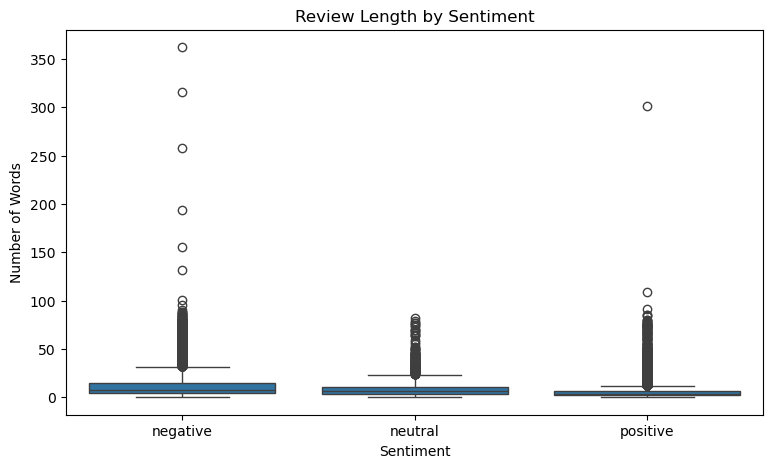

In [17]:
# ============================================================
# 17. WORD COUNT DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='sentiment',
    y='word_count',
    order=sentiment_order
)

plt.title('Review Length by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Words')

plt.show()

In [18]:
# ============================================================
# 18. DUPLICATE REVIEWS
# ============================================================

duplicate_reviews = df['review_description'].duplicated().sum()

print(
    f"Number of duplicate reviews: {duplicate_reviews}"
)

if duplicate_reviews > 0:

    df.drop_duplicates(
        subset=['review_description'],
        inplace=True
    )

    df.reset_index(
        drop=True,
        inplace=True
    )

    print("Duplicate reviews removed.")

else:

    print("No duplicate reviews found.")

Number of duplicate reviews: 1046
Duplicate reviews removed.


In [19]:
# ============================================================
# 19. CHECK EMPTY REVIEWS
# ============================================================

empty_reviews = (
    df['review_no_stopwords']
    .str.strip()
    .eq('')
    .sum()
)

print(
    f"Number of empty reviews after preprocessing: "
    f"{empty_reviews}"
)

df = df[
    df['review_no_stopwords'].str.strip() != ''
].copy()

df.reset_index(
    drop=True,
    inplace=True
)

print("Dataset shape:")
print(df.shape)

Number of empty reviews after preprocessing: 1979
Dataset shape:
(37020, 8)


In [20]:
# ============================================================
# 20. DEFINE FEATURES AND TARGET
# ============================================================

X = df['review_no_stopwords']
y = df['sentiment']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
0                                                 رائع
1    برنامج رائع جدا يساعد علي تلبيه الاحتياجات بشك...
2    التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...
3                      لماذا لا يمكننا طلب ماكدونالدز؟
4    البرنامج بيظهر المطاعم مغلقه انها بتكون فاتحه ...
Name: review_no_stopwords, dtype: str

Target:
0    positive
1    positive
2    negative
3    negative
4    negative
Name: sentiment, dtype: str


In [21]:
# ============================================================
# 21. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining sentiment distribution:")
display(y_train.value_counts(normalize=True).round(3))

print("\nTesting sentiment distribution:")
display(y_test.value_counts(normalize=True).round(3))

Training samples: 29616
Testing samples: 7404

Training sentiment distribution:


sentiment
positive    0.583
negative    0.367
neutral     0.050
Name: proportion, dtype: float64


Testing sentiment distribution:


sentiment
positive    0.583
negative    0.367
neutral     0.050
Name: proportion, dtype: float64

In [22]:
# ============================================================
# 22. TF-IDF VECTORIZATION
# ============================================================

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF training shape:")
print(X_train_tfidf.shape)

print("\nTF-IDF testing shape:")
print(X_test_tfidf.shape)

TF-IDF training shape:
(29616, 5000)

TF-IDF testing shape:
(7404, 5000)


In [23]:
# ============================================================
# 23. TRAIN LOGISTIC REGRESSION
# ============================================================

model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_tfidf,
    y_train
)

print("Model trained successfully.")

Model trained successfully.


In [24]:
# ============================================================
# 24. MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(X_test_tfidf)

print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
['negative' 'positive' 'neutral' 'positive' 'positive' 'negative'
 'negative' 'positive' 'negative' 'positive' 'positive' 'positive'
 'positive' 'positive' 'negative' 'negative' 'positive' 'neutral'
 'positive' 'positive']


In [25]:
# ============================================================
# 25. ACCURACY
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8306


In [26]:
# ============================================================
# 26. CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        y_pred,
        labels=['negative', 'neutral', 'positive']
    )
)

              precision    recall  f1-score   support

    negative       0.82      0.80      0.81      2720
     neutral       0.19      0.01      0.02       369
    positive       0.84      0.92      0.88      4315

    accuracy                           0.83      7404
   macro avg       0.62      0.58      0.57      7404
weighted avg       0.80      0.83      0.81      7404



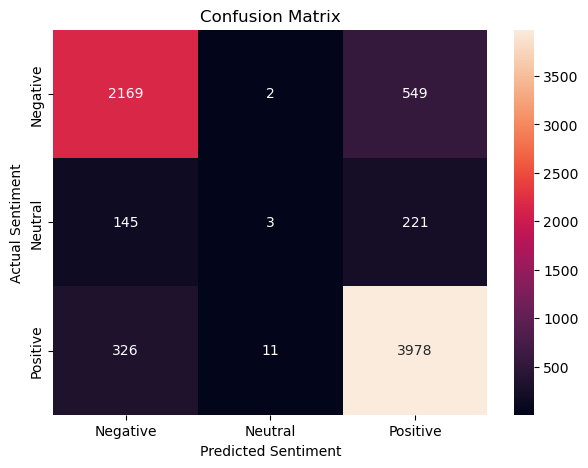

In [27]:
# ============================================================
# 27. CONFUSION MATRIX
# ============================================================

labels = [
    'negative',
    'neutral',
    'positive'
]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=[
        'Negative',
        'Neutral',
        'Positive'
    ],
    yticklabels=[
        'Negative',
        'Neutral',
        'Positive'
    ]
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')

plt.show()

In [28]:
# ============================================================
# 28. TOP WORDS FOR EACH SENTIMENT
# ============================================================

feature_names = np.array(
    tfidf.get_feature_names_out()
)

coefficients = model.coef_

classes = model.classes_

print("Classes:")
print(classes)

Classes:
['negative' 'neutral' 'positive']


In [29]:
# ============================================================
# 29. TOP FEATURES FOR EACH CLASS
# ============================================================

for i, class_name in enumerate(classes):

    top_indices = coefficients[i].argsort()[-20:][::-1]

    print(f"\nTop words associated with '{class_name}':")

    print(
        feature_names[top_indices]
    )


Top words associated with 'negative':
['سيء' 'فاشل' 'سئ' 'زباله' 'سيئ' 'اسوء' 'سيئه' 'زفت' 'لا انصح' 'فاشله'
 'اسوا' 'ساعتين' 'نجمه' 'نصابين' 'للاسف' 'وحش' 'سي' 'اعلانات' 'حراميه'
 'اوسخ']

Top words associated with 'neutral':
['جيد' 'يحتاج' 'اضافه' 'عربيه' 'المطاعم' 'المشكله' 'صغير' 'المسافه' 'نجوم'
 'احيانا' 'لاكن' 'تحديد' 'استفسار' 'الاستخدام' 'مو موجود' 'صادق' 'تحطو'
 'مدن' 'البرومو' 'برجاء']

Top words associated with 'positive':
['ممتازه' 'رائع' 'ممتاز' 'شكرا' 'روعه' 'رائعه' 'جميل' 'اروع' 'سهل'
 'افضل تطبيق' 'سريع' 'احب' 'احلي' 'افضل' 'مره حلو' 'يجنن' 'تطبيق ممتاز'
 'محترمه' 'بجنن' 'اجمل']


In [30]:
# ============================================================
# 30. TEST NEW REVIEWS
# ============================================================

new_reviews = [
    "الخدمة ممتازة والمكان جميل جدا",
    "الخدمة وحشة جدا ومش هكرر التجربة",
    "التجربة كانت عادية"
]

new_reviews_tfidf = tfidf.transform(
    new_reviews
)

predictions = model.predict(
    new_reviews_tfidf
)

for review, prediction in zip(
    new_reviews,
    predictions
):
    print(f"Review: {review}")
    print(f"Predicted sentiment: {prediction}")
    print("-" * 50)

Review: الخدمة ممتازة والمكان جميل جدا
Predicted sentiment: positive
--------------------------------------------------
Review: الخدمة وحشة جدا ومش هكرر التجربة
Predicted sentiment: negative
--------------------------------------------------
Review: التجربة كانت عادية
Predicted sentiment: positive
--------------------------------------------------
